# Pattern Search con Algoritmo di Grover

## 1. Importazione delle Librerie

Questo notebook implementa un algoritmo quantistico per la ricerca di pattern in una griglia 3x3 di pixel binari (512 possibili immagini).

**Librerie utilizzate:**
- `qiskit`: Framework principale per la computazione quantistica
- `qiskit_aer`: Simulatori quantistici (AerSimulator)
- `qiskit_aer.noise`: Modelli di rumore (bit-flip, depolarizing)
- `qiskit_ibm_runtime.fake_provider`: Backend simulati realistici (FakeKolkata)
- `matplotlib`: Visualizzazione dei risultati

In [31]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, Operator
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import Aer
import math
import numpy as np

In [32]:

# Funzione per creare l'oracolo
def full_oracle():
    qc = QuantumCircuit(10)
    qc.mcx(list(range(9)), 9)
    return qc.to_gate(label="Full Oracle")

def diagonal_oracle():
    qc = QuantumCircuit(10)
    
    A = [0, 4, 8]
    B = [2, 4, 6]
    
    qc.mcx(A, 9)
    qc.mcx(B, 9)
    
    qc.mcx(list(set(A) | set(B)), 9)
    
    return qc.to_gate(label="Diagonal Oracle")

def vertical_oracle():
    qc = QuantumCircuit(10)

    A = [0, 3, 6]
    B = [1, 4, 7]
    C = [2, 5, 8]

    qc.mcx(A, 9)
    qc.mcx(B, 9)
    qc.mcx(C, 9)

    qc.mcx(A + B, 9)
    qc.mcx(A + C, 9)
    qc.mcx(B + C, 9)

    qc.mcx(A + B + C, 9)

    return qc.to_gate(label="Vertical Oracle")
    

def square_oracle():
    qc = QuantumCircuit(10)
    
    A = [0, 1, 3, 4]
    B = [1, 2, 4, 5]
    C = [3, 4, 6, 7]
    D = [4, 5, 7, 8]
    
    qc.mcx(A, 9)
    qc.mcx(B, 9)
    qc.mcx(C, 9)
    qc.mcx(D, 9)
    
    qc.mcx(list(set(A) | set(B)), 9)
    qc.mcx(list(set(A) | set(C)), 9)
    qc.mcx(list(set(A) | set(D)), 9)
    qc.mcx(list(set(B) | set(C)), 9)
    qc.mcx(list(set(B) | set(D)), 9)
    qc.mcx(list(set(C) | set(D)), 9)
    
    qc.mcx(list(set(A) | set(B) | set(C)), 9)
    qc.mcx(list(set(A) | set(B) | set(D)), 9)
    qc.mcx(list(set(A) | set(C) | set(D)), 9)
    qc.mcx(list(set(B) | set(C) | set(D)), 9)
    
    qc.mcx(list(set(A) | set(B) | set(C) | set(D)), 9)
    
    return qc.to_gate(label="Square Oracle")


## 2. Definizione degli Oracle

Gli oracle sono funzioni quantistiche che "marcano" le soluzioni valide invertendo la loro fase.

**Oracle implementati:**

| Oracle | Pattern | Soluzioni | Descrizione |
|--------|---------|-----------|-------------|
| **Vertical** | I | 169 | Tre pixel "on" in una colonna |
| **Square** | :: | 95 | Quadrato 2x2 di pixel "on" |
| **Diagonal** | \\ o / | 112 | Diagonale principale o secondaria |
| **Full** | # | 1 | Tutti i 9 pixel "on" |

**Mapping della griglia:**
```
q0 q1 q2
q3 q4 q5  ->  9 qubit di dati + 1 qubit ancilla (q9)
q6 q7 q8
```

**Implementazione:** Utilizziamo porte MCX (Multi-Controlled X) per marcare i pattern validi.

In [ ]:
# OPERATORE DI DIFFUSIONE DI GROVER

def grover_u_psi():
    """
    Operatore di diffusione di Grover: 2|psi><psi| - I
    dove |psi> = H^n |0> e' la superposizione uniforme
    """
    u_psi = QuantumCircuit(9)

    u_psi.h(range(9))

    u_psi.x(range(9)) 

    # Multi-controlled Z (fase -1 se tutti i qubit sono 1)
    u_psi.h(8)
    u_psi.mcx(list(range(8)), 8)
    u_psi.h(8)

    u_psi.z(0)          # Prima Z sul qubit 0
    u_psi.x(range(9)) 
    u_psi.z(0)          # Z sul qubit 0

    # H per tornare alla base computazionale
    u_psi.h(range(9))
    
    return u_psi.to_gate(label="Diffusion")

# ALGORITMO DI GROVER
def algoritmo_grover(oracle, num_soluzioni=1):
    """
    Costruisce il circuito di Grover per trovare le soluzioni marcate dall'oracolo.
    
    Args:
        oracle: Gate oracolo che marca le soluzioni (fase -1)
        num_soluzioni: Numero di soluzioni marcate dall'oracolo
    
    Il numero ottimale di iterazioni e' k = round(pi/(4*theta) - 0.5)
    dove theta = arcsin(sqrt(M/N)), N = 2^n (numero totale stati), M = numero soluzioni
    """
    grover_iteration = QuantumCircuit(10)
    grover_iteration.append(oracle, range(10))
    grover_iteration.append(grover_u_psi(), range(9))
    
    # Calcolo numero ottimale di iterazioni (formula esatta trigonometrica)
    N = 2**9  # 512 stati
    theta = math.asin(math.sqrt(num_soluzioni / N))
    num_iterazioni = max(1, round((math.pi / (4 * theta)) - 0.5))
    print(f"Numero iterazioni ottimale: {num_iterazioni}")
    
    # Costruzione del circuito completo di Grover
    grover_circuit = QuantumCircuit(10)
    
    # Superposizione uniforme sui 9 qubit di dati
    grover_circuit.h(range(9))
    
    # Qubit ancilla in stato |->  per phase kickback
    grover_circuit.x(9)
    grover_circuit.h(9)
    
    # Applicazione iterazioni di Grover
    for _ in range(num_iterazioni):
        grover_circuit.append(grover_iteration.to_gate(label='G'), range(10))
        
    return grover_circuit

## 3. Algoritmo di Grover

L'algoritmo di Grover fornisce un speedup quadratico per la ricerca non strutturata: **O(sqrt(N))** invece di **O(N)**.

**Componenti:**

1. **Inizializzazione:** Superposizione uniforme con porte Hadamard
2. **Oracle:** Inverte la fase delle soluzioni valide
3. **Diffusore (U_psi):** Amplifica l'ampiezza delle soluzioni marcate

**Formula per le iterazioni ottimali:**

```
k = round(pi / (4 * theta) - 0.5)
theta = arcsin(sqrt(M / N))
```

dove M = numero di soluzioni, N = 512 stati totali.


CIRCUITI DEGLI ORACLE

Mappatura griglia 3x3 -> qubit:
  q0 | q1 | q2
  q3 | q4 | q5
  q6 | q7 | q8
  q9 = ancilla (target)

 FULL ORACLE 
Numero di MCX gates: 1


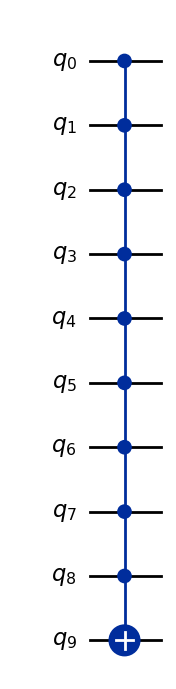


 DIAGONAL ORACLE 
Numero di MCX gates: 3


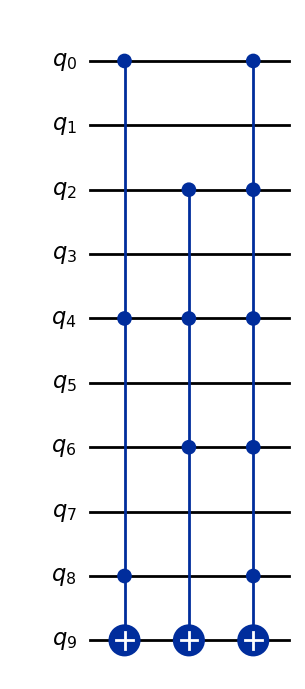


 VERTICAL ORACLE 
Numero di MCX gates: 7


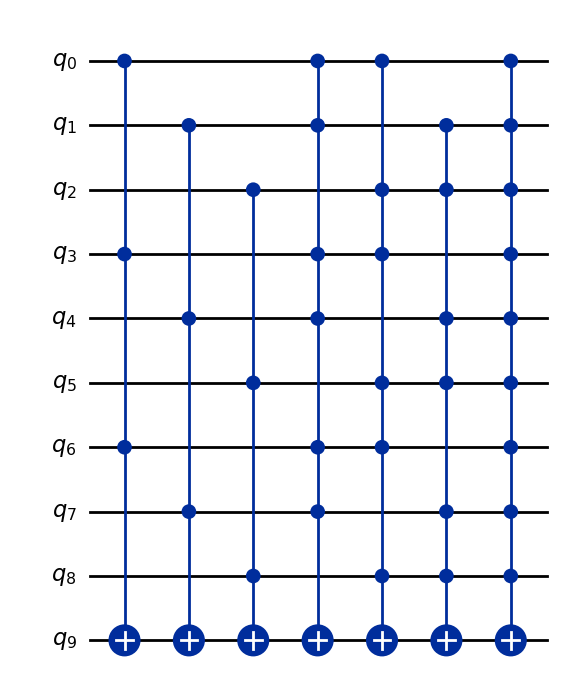


 SQUARE ORACLE 
Numero di MCX gates: 15


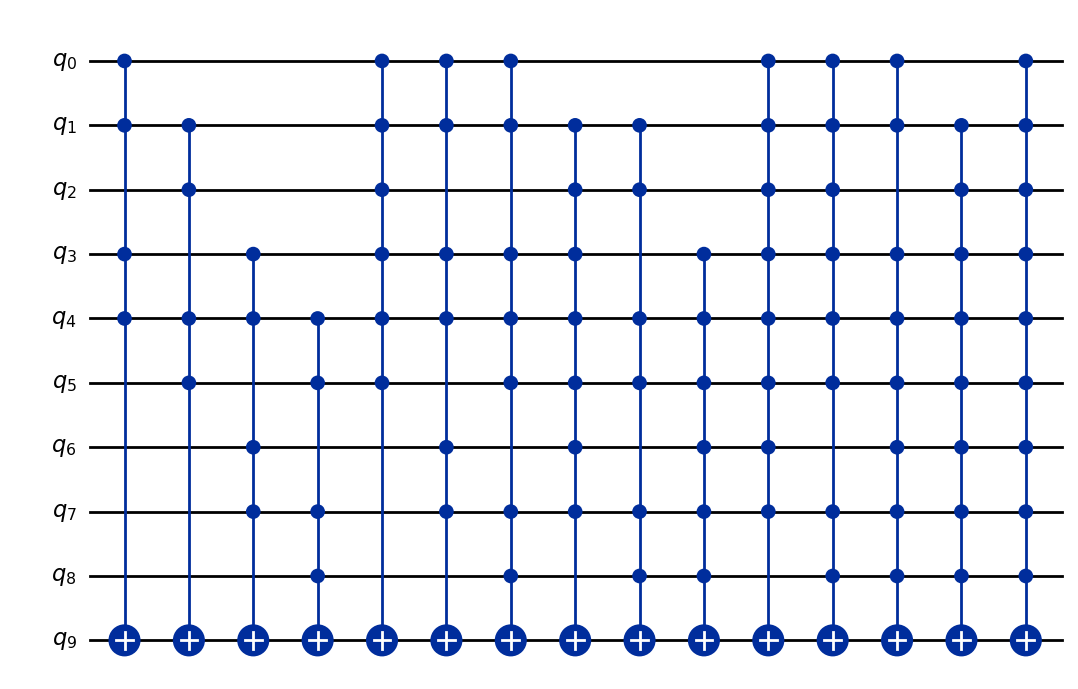

In [34]:
# VISUALIZZAZIONE CIRCUITI ORACLE
def crea_oracle_circuito(nome):
    """Crea il circuito di un oracle (senza convertirlo a gate, per vedere i dettagli)"""
    qc = QuantumCircuit(10)
    
    if nome == 'full':
        qc.mcx(list(range(9)), 9)
    elif nome == 'diagonal':
        A, B = [0, 4, 8], [2, 4, 6]
        qc.mcx(A, 9)
        qc.mcx(B, 9)
        qc.mcx(list(set(A) | set(B)), 9)
    elif nome == 'vertical':
        A, B, C = [0, 3, 6], [1, 4, 7], [2, 5, 8]
        qc.mcx(A, 9)
        qc.mcx(B, 9)
        qc.mcx(C, 9)
        qc.mcx(A + B, 9)
        qc.mcx(A + C, 9)
        qc.mcx(B + C, 9)
        qc.mcx(A + B + C, 9)
    elif nome == 'square':
        A, B = [0, 1, 3, 4], [1, 2, 4, 5]
        C, D = [3, 4, 6, 7], [4, 5, 7, 8]
        qc.mcx(A, 9)
        qc.mcx(B, 9)
        qc.mcx(C, 9)
        qc.mcx(D, 9)
        qc.mcx(list(set(A)|set(B)), 9)
        qc.mcx(list(set(A)|set(C)), 9)
        qc.mcx(list(set(A)|set(D)), 9)
        qc.mcx(list(set(B)|set(C)), 9)
        qc.mcx(list(set(B)|set(D)), 9)
        qc.mcx(list(set(C)|set(D)), 9)
        qc.mcx(list(set(A)|set(B)|set(C)), 9)
        qc.mcx(list(set(A)|set(B)|set(D)), 9)
        qc.mcx(list(set(A)|set(C)|set(D)), 9)
        qc.mcx(list(set(B)|set(C)|set(D)), 9)
        qc.mcx(list(set(A)|set(B)|set(C)|set(D)), 9)
    
    return qc

print("CIRCUITI DEGLI ORACLE")
print("\nMappatura griglia 3x3 -> qubit:")
print("  q0 | q1 | q2")
print("  q3 | q4 | q5")
print("  q6 | q7 | q8")
print("  q9 = ancilla (target)")

# Mostra i circuiti di tutti gli oracle
for nome in ['full', 'diagonal', 'vertical', 'square']:
    print(f"\n {nome.upper()} ORACLE ")
    qc = crea_oracle_circuito(nome)
    print(f"Numero di MCX gates: {qc.count_ops().get('mcx', 0)}")
    display(qc.draw('mpl', style='iqp', fold=-1))

## 4. Simulazione Senza Rumore (Ideale)

Testiamo l'algoritmo su **AerSimulator** senza modelli di rumore per stabilire una baseline di performance.

**Metriche misurate:**
- Probabilita di successo (% di shots che trovano una soluzione valida)
- Confronto con probabilita uniforme (ricerca casuale classica)
- Fattore di amplificazione quantistica


CIRCUITI GROVER COMPLETI

Struttura: Init -> Oracle -> Diffusion -> Measure

GROVER CON FULL ORACLE 


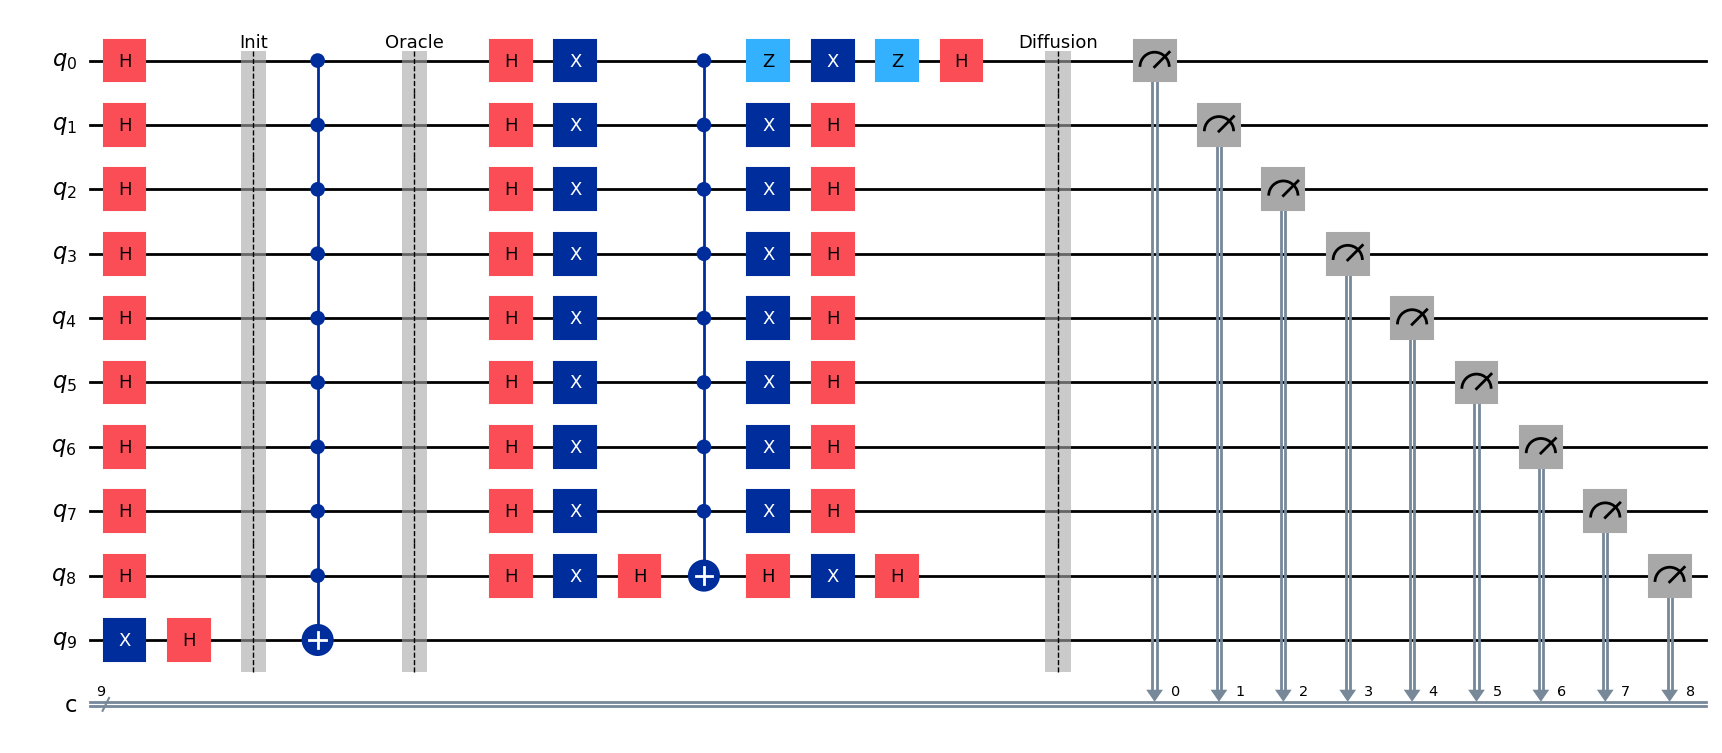


GROVER CON DIAGONAL ORACLE 


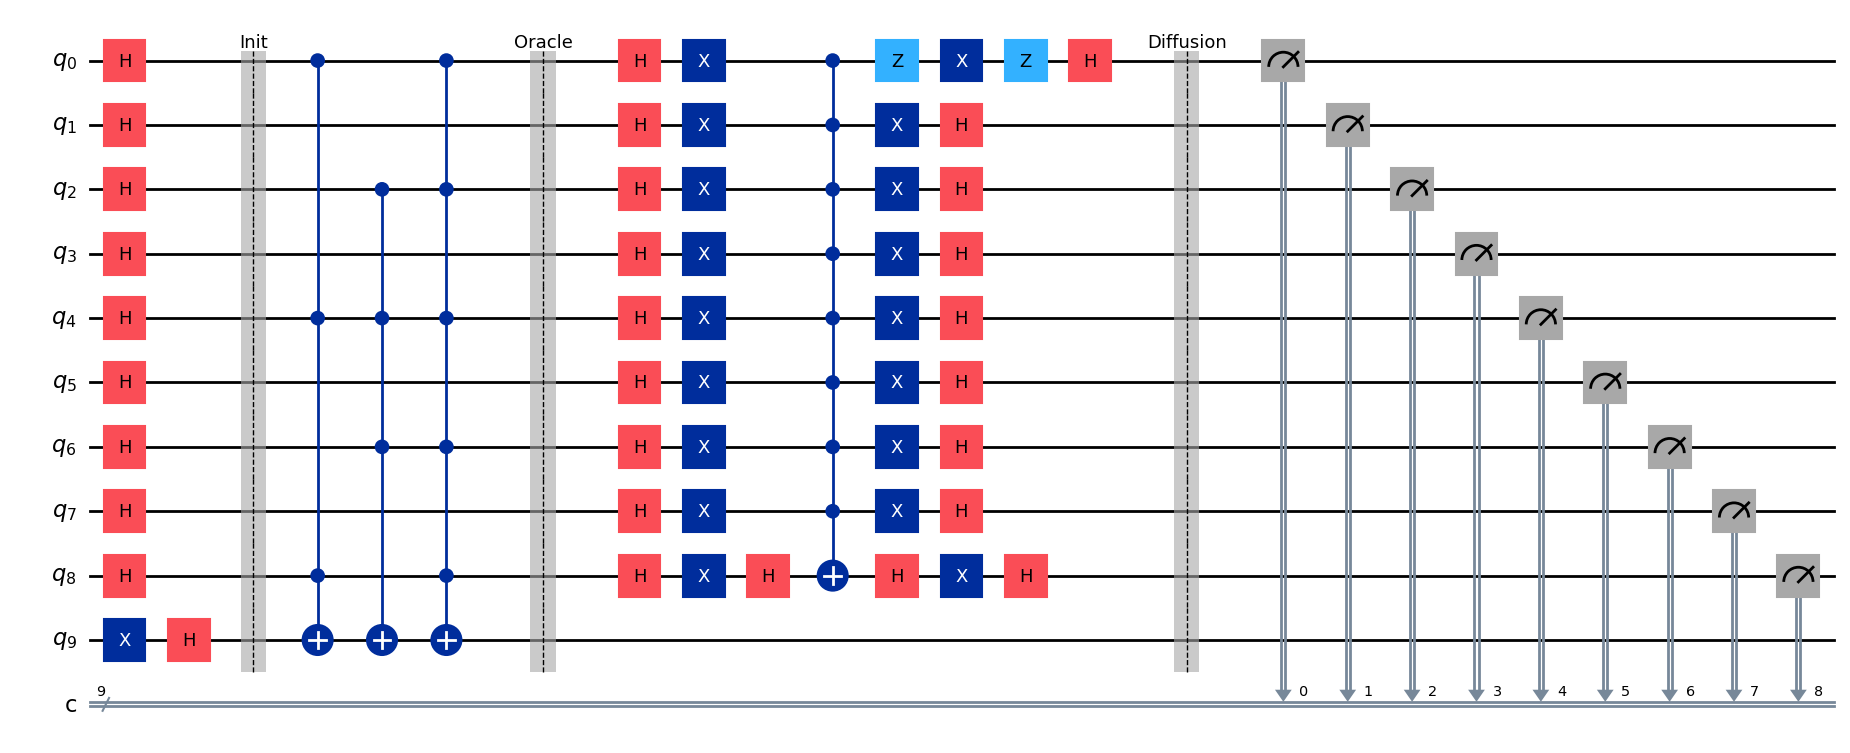


GROVER CON VERTICAL ORACLE 


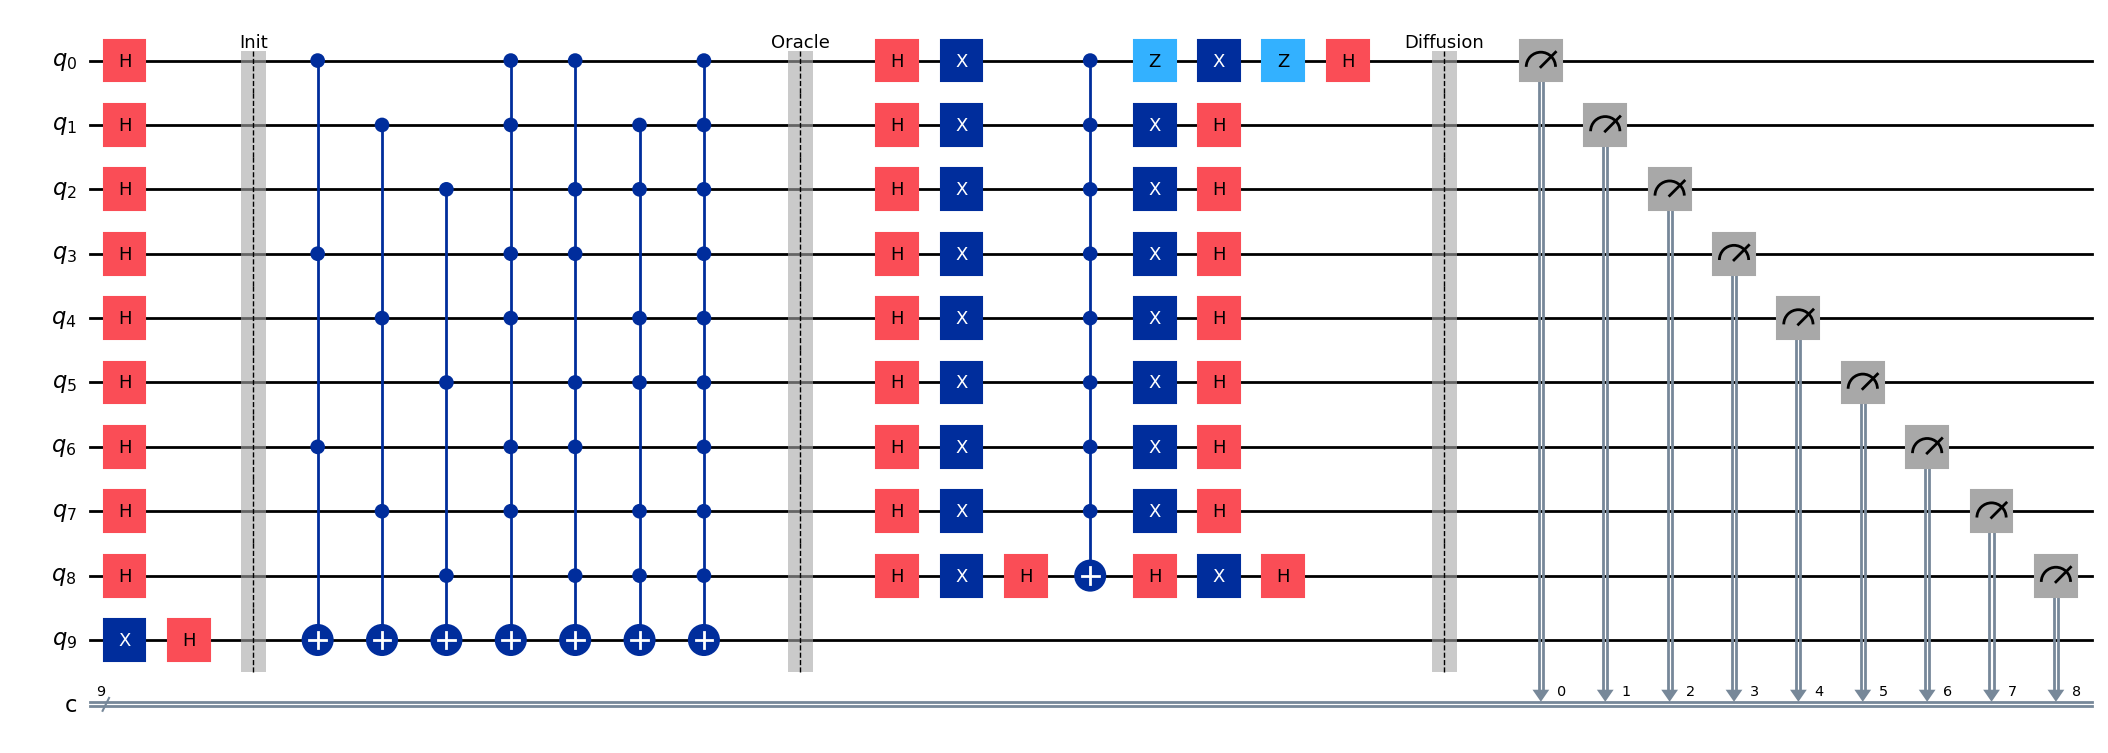


GROVER CON SQUARE ORACLE 


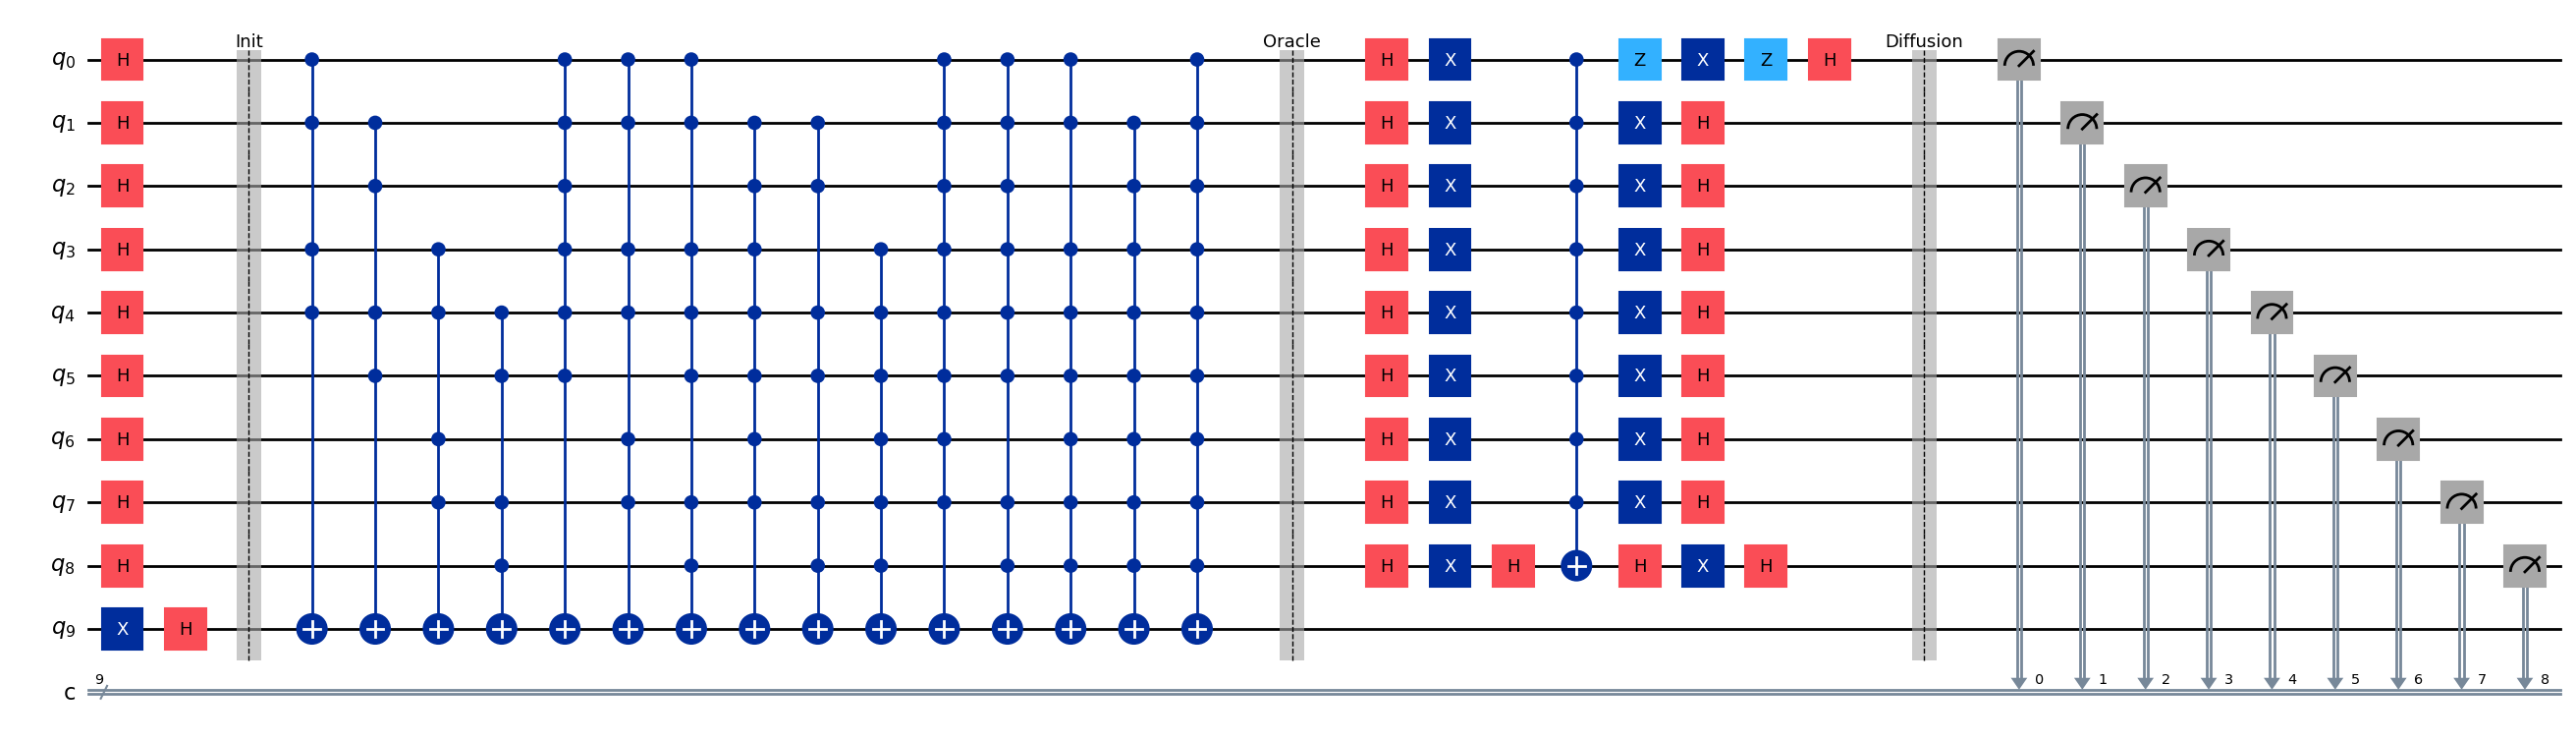

OPERATORE DI DIFFUSIONE (dettaglio)
Implementa: 2|psi><psi| - I
Sequenza: H -> X -> MCZ -> X -> H


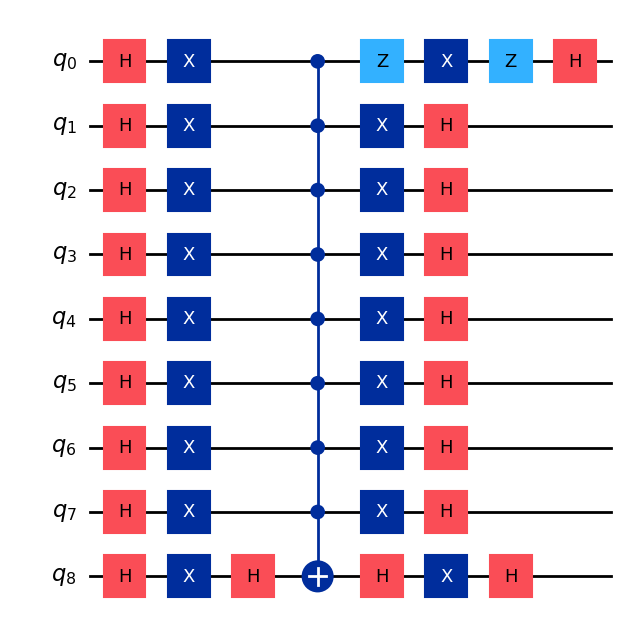

In [35]:
# VISUALIZZAZIONE CIRCUITO GROVER COMPLETO (per ogni oracle)

print("CIRCUITI GROVER COMPLETI")
print("\nStruttura: Init -> Oracle -> Diffusion -> Measure")

for nome in ['full', 'diagonal', 'vertical', 'square']:
    print(f"\nGROVER CON {nome.upper()} ORACLE ")
    
    qc = QuantumCircuit(10, 9)
    
    # Inizializzazione
    qc.h(range(9))
    qc.x(9)
    qc.h(9)
    qc.barrier(label="Init")
    
    # Oracle
    oracle_qc = crea_oracle_circuito(nome)
    qc.compose(oracle_qc, inplace=True)
    qc.barrier(label="Oracle")
    
    # Diffusione (esplicitata)
    qc.h(range(9))
    qc.x(range(9))
    qc.h(8)
    qc.mcx(list(range(8)), 8)
    qc.h(8)
    qc.z(0)          # Prima Z sul qubit 0
    qc.x(range(9))
    qc.z(0)          # Z sul qubit 0
    qc.h(range(9))
    qc.barrier(label="Diffusion")
    
    # Misura
    qc.measure(range(9), range(9))
    
    display(qc.draw('mpl', style='iqp', fold=-1))

# Mostra anche l'operatore di diffusione isolato
print("OPERATORE DI DIFFUSIONE (dettaglio)")
print("Implementa: 2|psi><psi| - I")
print("Sequenza: H -> X -> MCZ -> X -> H")

qc_diff = QuantumCircuit(9)
qc_diff.h(range(9))
qc_diff.x(range(9))

qc_diff.h(8)
qc_diff.mcx(list(range(8)), 8)
qc_diff.h(8)

qc_diff.z(0)          # Prima Z sul qubit 0
qc_diff.x(range(9))
qc_diff.z(0)          # Z sul qubit 0

qc_diff.h(range(9))

display(qc_diff.draw('mpl', style='iqp', fold=-1))

In [ ]:
# TEST COMPLETO DI TUTTI GLI ORACLE

# Configurazione oracle con numero soluzioni e funzione di verifica
ORACLE_CONFIG = {
    'vertical': {
        'oracle': vertical_oracle(),
        'num_soluzioni': 169,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[3]=='1' and bits[6]=='1') or  # Colonna 0
            (bits[1]=='1' and bits[4]=='1' and bits[7]=='1') or  # Colonna 1
            (bits[2]=='1' and bits[5]=='1' and bits[8]=='1')     # Colonna 2
        ),
        'descrizione': 'Linea verticale di 3 pixel'
    },
    'square': {
        'oracle': square_oracle(),
        'num_soluzioni': 95,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[1]=='1' and bits[3]=='1' and bits[4]=='1') or  # Top-left
            (bits[1]=='1' and bits[2]=='1' and bits[4]=='1' and bits[5]=='1') or  # Top-right
            (bits[3]=='1' and bits[4]=='1' and bits[6]=='1' and bits[7]=='1') or  # Bottom-left
            (bits[4]=='1' and bits[5]=='1' and bits[7]=='1' and bits[8]=='1')     # Bottom-right
        ),
        'descrizione': 'Quadrato 2x2 di pixel'
    },
    'diagonal': {
        'oracle': diagonal_oracle(),
        'num_soluzioni': 112,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[4]=='1' and bits[8]=='1') or  # Diagonale principale
            (bits[2]=='1' and bits[4]=='1' and bits[6]=='1')     # Anti-diagonale
        ),
        'descrizione': 'Diagonale di 3 pixel'
    },
    'full': {
        'oracle': full_oracle(),
        'num_soluzioni': 1,
        'verifica': lambda bits: all(b=='1' for b in bits),
        'descrizione': 'Tutti i 9 pixel ON'
    }
}

def show_as_matrix(bitstring):
    """Converte bitstring Qiskit in matrice 3x3"""
    bits = bitstring[::-1]
    lines = []
    for row in range(3):
        line = " | ".join(bits[row*3 + col] for col in range(3))
        lines.append(line)
    return "\n".join(lines)

def test_oracle(nome, config, shots=10000):
    """Esegue test completo per un oracle"""
    oracle = config['oracle']
    num_soluzioni = config['num_soluzioni']
    verifica = config['verifica']
    
    # Costruzione circuito
    qc = QuantumCircuit(10, 9)
    qc.append(algoritmo_grover(oracle, num_soluzioni), range(10))
    qc.measure(range(9), range(9))
    
    # Esecuzione
    backend = Aer.get_backend('aer_simulator')
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts(qc)
    
    # Analisi risultati
    soluzioni_trovate = sum(freq for stato, freq in counts.items() 
                           if verifica(stato[::-1]))
    perc_successo = soluzioni_trovate / shots * 100
    perc_uniforme = num_soluzioni / 512 * 100
    
    # Output
    print(f"\nORACLE: {nome.upper()} - {config['descrizione']}")
    print(f"Soluzioni nel database:   {num_soluzioni}/512 ({perc_uniforme:.1f}%)")
    print(f"Soluzioni trovate:        {soluzioni_trovate}/{shots} ({perc_successo:.1f}%)")
    print(f"Amplificazione Grover:    {perc_successo/perc_uniforme:.2f}x")
    
    return {
        'nome': nome,
        'successo': perc_successo,
        'uniforme': perc_uniforme,
        'amplificazione': perc_successo/perc_uniforme
    }

# Esegui test per tutti gli oracle
print("TESTING TUTTI GLI ORACLE")

risultati = []
for nome, config in ORACLE_CONFIG.items():
    r = test_oracle(nome, config)
    risultati.append(r)

# Riepilogo finale
print("\n\nRIEPILOGO CONFRONTO GROVER vs CLASSICO")
print(f"{'Oracle':<12} {'Classico':<12} {'Grover':<12} {'Speedup':<10}")
print("-"*60)
for r in risultati:
    print(f"{r['nome']:<12} {r['uniforme']:.1f}%{'':<6} {r['successo']:.1f}%{'':<6} {r['amplificazione']:.2f}x")

TESTING TUTTI GLI ORACLE RICHIESTI DAL PROGETTO
Numero iterazioni ottimale: 1

ORACLE: VERTICAL - Linea verticale di 3 pixel
Soluzioni nel database:   169/512 (33.0%)
Soluzioni trovate:        9276/10000 (92.8%)
Amplificazione Grover:    2.81x
Numero iterazioni ottimale: 1

ORACLE: SQUARE - Quadrato 2x2 di pixel
Soluzioni nel database:   95/512 (18.6%)
Soluzioni trovate:        9442/10000 (94.4%)
Amplificazione Grover:    5.09x
Numero iterazioni ottimale: 1

ORACLE: DIAGONAL - Diagonale di 3 pixel
Soluzioni nel database:   112/512 (21.9%)
Soluzioni trovate:        9882/10000 (98.8%)
Amplificazione Grover:    4.52x
Numero iterazioni ottimale: 17

ORACLE: FULL - Tutti i 9 pixel ON
Soluzioni nel database:   1/512 (0.2%)
Soluzioni trovate:        9995/10000 (100.0%)
Amplificazione Grover:    511.74x


RIEPILOGO CONFRONTO GROVER vs CLASSICO
Oracle       Classico     Grover       Speedup   
------------------------------------------------------------
vertical     33.0%       92.8%       2.81

## 5. Modelli di Rumore Quantistico

I computer quantistici reali sono soggetti a errori. Simuliamo due tipi di rumore:

### 5.1 Bit-Flip (X error)
```
E(rho) = (1-p) * rho + p * X * rho * X
```
Simula errori che invertono lo stato del qubit: |0> <-> |1>

### 5.2 Depolarizing
```
E(rho) = (1-p) * rho + (p/3) * (X*rho*X + Y*rho*Y + Z*rho*Z)
```
Simula errori casuali in tutte le direzioni. **Piu realistico e piu dannoso.**

**Tassi di errore testati:** p = 0.001, 0.005, 0.01, 0.02, 0.05

In [ ]:
# MODELLI DI RUMORE: BIT FLIP E DEPOLARIZING CHANNEL

from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error
import time

def create_bitflip_noise_model(p_error):
    """
    Crea un modello di rumore bit-flip.
    
    Canale: E(rho) = (1-p)*rho + p*X*rho*X
    
    - Con probabilità (1-p): lo stato rimane invariato
    - Con probabilità p: viene applicato il bit-flip X
    
    p = probabilità di ERRORE (bit-flip)
    """
    noise_model = NoiseModel()
    
    # Errore bit-flip: probabilità (1-p) per I, probabilità p per X
    bit_flip = pauli_error([('I', 1 - p_error), ('X', p_error)])
    
    # Applica l'errore dopo ogni gate a 1 qubit
    noise_model.add_all_qubit_quantum_error(bit_flip, ['u1', 'u2', 'u3', 'x', 'y', 'z', 'h', 's', 't'])
    
    # Per gate a 2 qubit, applica errore su entrambi
    bit_flip_2q = bit_flip.tensor(bit_flip)
    noise_model.add_all_qubit_quantum_error(bit_flip_2q, ['cx', 'cz', 'swap'])
    
    return noise_model


def create_depolarizing_noise_model(p_error):
    """
    Crea un modello di rumore depolarizing.
    
    Formula: E(rho) = (1-p)*rho + p*(I/2)
    
    """
    noise_model = NoiseModel()
    
    p_I = 1 - p_error
    p_X = p_error/3
    p_Y = p_error/3
    p_Z = p_error/3
    
    # Errore depolarizing per gate a 1 qubit usando pauli_error
    depol_1q = pauli_error([('I', p_I), ('X', p_X), ('Y', p_Y), ('Z', p_Z)])
    noise_model.add_all_qubit_quantum_error(depol_1q, ['u1', 'u2', 'u3', 'x', 'y', 'z', 'h', 's', 't'])
    
    # Per gate a 2 qubit, applica errore su entrambi
    depol_2q = depol_1q.tensor(depol_1q)
    noise_model.add_all_qubit_quantum_error(depol_2q, ['cx', 'cz', 'swap'])
    
    return noise_model


def test_with_noise(oracle, num_soluzioni, verifica_fn, noise_model, noise_name, shots=10000):
    
    grover_circ = algoritmo_grover(oracle, num_soluzioni)
    qc = QuantumCircuit(10, 9)
    qc.append(grover_circ, range(10))
    qc.measure(range(9), range(9))
    
    start = time.time()
    sim = AerSimulator(noise_model=noise_model)
    qc_transpiled = transpile(qc, sim)
    
    result = sim.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()
    
    # Calcola successo
    successo = sum(c for stato, c in counts.items() if verifica_fn(stato)) / shots * 100
    
    elapsed = time.time() - start
    
    return {
        'successo': successo,
        'counts': counts,
        'noise_name': noise_name,
        'tempo': elapsed
    }

print("TEST CON MODELLI DI RUMORE: BIT-FLIP E DEPOLARIZING")
print("\nBIT-FLIP: E(rho) = (1-p)*rho + p*X*rho*X")
print("         p = probabilità di errore (bit-flip)")
print("\nDEPOLARIZING: E(rho) = (1-p)*rho + p*(I/2)")
print("              p = probabilità di depolarizzazione")

TEST CON MODELLI DI RUMORE: BIT-FLIP E DEPOLARIZING

BIT-FLIP: E(rho) = (1-p)*rho + p*X*rho*X
         p = probabilità di errore (bit-flip)

DEPOLARIZING: E(rho) = (1-p)*rho + p*(I/2)
              p = probabilità di depolarizzazione


In [38]:
# CONFRONTO NOISELESS vs BIT-FLIP vs DEPOLARIZING (TUTTI GLI ORACLE)

# Probabilità di errore da testare
ERROR_RATES = [0.001, 0.005, 0.01, 0.02, 0.05]

# TUTTI E 4 GLI ORACLE
TEST_ORACLES = {
    'vertical': {
        'oracle': vertical_oracle(),
        'num_soluzioni': 169,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[3]=='1' and bits[6]=='1') or
            (bits[1]=='1' and bits[4]=='1' and bits[7]=='1') or
            (bits[2]=='1' and bits[5]=='1' and bits[8]=='1')
        )
    },
    'square': {
        'oracle': square_oracle(),
        'num_soluzioni': 95,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[1]=='1' and bits[3]=='1' and bits[4]=='1') or
            (bits[1]=='1' and bits[2]=='1' and bits[4]=='1' and bits[5]=='1') or
            (bits[3]=='1' and bits[4]=='1' and bits[6]=='1' and bits[7]=='1') or
            (bits[4]=='1' and bits[5]=='1' and bits[7]=='1' and bits[8]=='1')
        )
    },
    'diagonal': {
        'oracle': diagonal_oracle(),
        'num_soluzioni': 112,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[4]=='1' and bits[8]=='1') or
            (bits[2]=='1' and bits[4]=='1' and bits[6]=='1')
        )
    },
    'full': {
        'oracle': full_oracle(),
        'num_soluzioni': 1,
        'verifica': lambda bits: all(b=='1' for b in bits)
    }
}

# Raccogli tutti i risultati
all_results = {}

for oracle_name, config in TEST_ORACLES.items():
    print(f"\nTESTING ORACLE: {oracle_name.upper()}")
    
    oracle = config['oracle']
    num_sol = config['num_soluzioni']
    verifica = config['verifica']
    perc_uniforme = num_sol / 512 * 100
    
    results_for_oracle = {
        'noiseless': None,
        'bitflip': {},
        'depolarizing': {}
    }
    
    # Test NOISELESS
    print(f"\n[1/3] Simulazione NOISELESS...")
    qc = QuantumCircuit(10, 9)
    qc.append(algoritmo_grover(oracle, num_sol), range(10))
    qc.measure(range(9), range(9))
    
    backend = AerSimulator()
    compiled = transpile(qc, backend)
    start = time.time()
    result = backend.run(compiled, shots=10000).result()
    t_noiseless = time.time() - start
    counts = result.get_counts(qc)
    sol_noiseless = sum(f for s, f in counts.items() if verifica(s[::-1]))
    perc_noiseless = sol_noiseless / 10000 * 100
    
    results_for_oracle['noiseless'] = {
        'successo': perc_noiseless,
        'tempo': t_noiseless
    }
    print(f"   Successo: {perc_noiseless:.1f}% | Tempo: {t_noiseless:.3f}s")
    
    # Test BIT-FLIP con diverse probabilità
    print(f"\n[2/3] Simulazione BIT-FLIP: E(rho) = (1-p)*rho + p*X*rho*X...")
    for p in ERROR_RATES:
        noise_model = create_bitflip_noise_model(p)
        r = test_with_noise(oracle, num_sol, verifica, noise_model, f"bitflip_{p}")
        results_for_oracle['bitflip'][p] = r
        print(f"   p={p:.3f}: Successo={r['successo']:.1f}% | Tempo={r['tempo']:.3f}s")
    
    # Test DEPOLARIZING con diverse probabilità
    print(f"\n[3/3] Simulazione DEPOLARIZING: E(rho) = (1-p)*rho + p*(I/2)...")
    for p in ERROR_RATES:
        noise_model = create_depolarizing_noise_model(p)
        r = test_with_noise(oracle, num_sol, verifica, noise_model, f"depol_{p}")
        results_for_oracle['depolarizing'][p] = r
        print(f"   p={p:.3f}: Successo={r['successo']:.1f}% | Tempo={r['tempo']:.3f}s")
    
    all_results[oracle_name] = results_for_oracle
    
    # Tabella riepilogativa per questo oracle
    print(f"\nRIEPILOGO {oracle_name.upper()} - Successo teorico classico: {perc_uniforme:.1f}%")
    print(f"{'Modello':<25} {'Successo':<15} {'Degradazione':<15}")
    print("-"*70)
    print(f"{'Noiseless':<25} {perc_noiseless:.1f}%{'':<10} (baseline)")
    
    for p in ERROR_RATES:
        bf = results_for_oracle['bitflip'][p]['successo']
        deg_bf = (perc_noiseless - bf) / perc_noiseless * 100 if perc_noiseless > 0 else 0
        print(f"{'Bit-flip p=' + str(p):<25} {bf:.1f}%{'':<10} -{deg_bf:.1f}%")
    
    for p in ERROR_RATES:
        dp = results_for_oracle['depolarizing'][p]['successo']
        deg_dp = (perc_noiseless - dp) / perc_noiseless * 100 if perc_noiseless > 0 else 0
        print(f"{'Depolarizing p=' + str(p):<25} {dp:.1f}%{'':<10} -{deg_dp:.1f}%")


TESTING ORACLE: VERTICAL

[1/3] Simulazione NOISELESS...
Numero iterazioni ottimale: 1
   Successo: 93.1% | Tempo: 0.030s

[2/3] Simulazione BIT-FLIP: E(rho) = (1-p)*rho + p*X*rho*X...
Numero iterazioni ottimale: 1
   p=0.001: Successo=47.5% | Tempo=3.714s
Numero iterazioni ottimale: 1
   p=0.005: Successo=32.9% | Tempo=3.380s
Numero iterazioni ottimale: 1
   p=0.010: Successo=33.2% | Tempo=3.677s
Numero iterazioni ottimale: 1
   p=0.020: Successo=33.6% | Tempo=3.378s
Numero iterazioni ottimale: 1
   p=0.050: Successo=33.3% | Tempo=3.579s

[3/3] Simulazione DEPOLARIZING: E(rho) = (1-p)*rho + p*(I/2)...
Numero iterazioni ottimale: 1
   p=0.001: Successo=44.0% | Tempo=3.947s
Numero iterazioni ottimale: 1
   p=0.005: Successo=32.2% | Tempo=3.396s
Numero iterazioni ottimale: 1
   p=0.010: Successo=32.7% | Tempo=3.678s
Numero iterazioni ottimale: 1
   p=0.020: Successo=33.1% | Tempo=3.183s
Numero iterazioni ottimale: 1
   p=0.050: Successo=32.2% | Tempo=3.428s

RIEPILOGO VERTICAL - Success

## 6. Valutazione dell'Impatto del Rumore

Confrontiamo le performance dell'algoritmo di Grover sotto diversi modelli di rumore.

**Ipotesi da verificare:**
1. Il rumore depolarizing degrada piu del bit-flip
2. La degradazione aumenta esponenzialmente con il tasso di errore


**Metriche:** Percentuale di successo e degradazione rispetto al caso ideale.

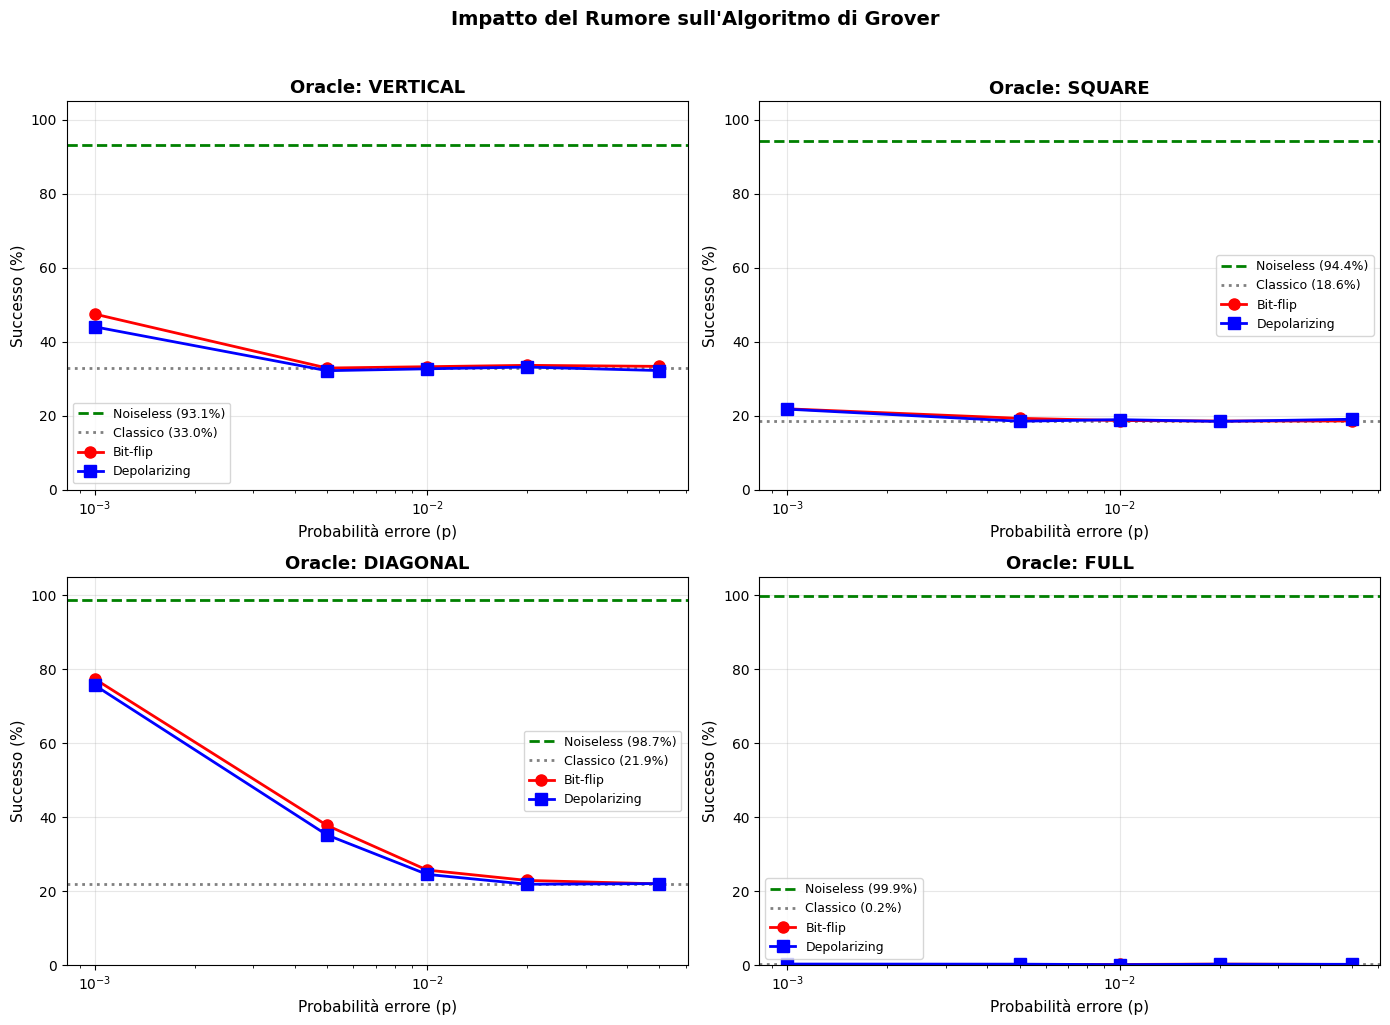


CONCLUSIONI

FORMULE DEI CANALI DI RUMORE (p = probabilità di ERRORE):

OSSERVAZIONI:

1. BIT-FLIP vs DEPOLARIZING:
   - Il bit-flip agisce SOLO sull'asse X (inversione |0>↔|1>)
   - Il depolarizing introduce errori su tutti e 3 gli assi (X, Y, Z)

2. SENSIBILITÀ AL RUMORE:
   - p=0.001 (0.1%): degradazione minima, Grover ancora efficace
   - p=0.01 (1%): degradazione moderata
   - p=0.05 (5%): degradazione significativa

3. IMPLICAZIONI PRATICHE:
   - I computer quantistici attuali hanno tassi di errore ~0.1-1%
   - La correzione degli errori quantistici (QEC) è essenziale
   - Grover mantiene vantaggio anche con rumore moderato



In [ ]:
# VISUALIZZAZIONE GRAFICA: IMPATTO DEL RUMORE

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (oracle_name, results) in enumerate(all_results.items()):
    ax = axes[idx]
    
    # Dati per il grafico
    noiseless_val = results['noiseless']['successo']
    bitflip_vals = [results['bitflip'][p]['successo'] for p in ERROR_RATES]
    depol_vals = [results['depolarizing'][p]['successo'] for p in ERROR_RATES]
    
    # Linea baseline noiseless
    ax.axhline(y=noiseless_val, color='green', linestyle='--', linewidth=2, label=f'Noiseless ({noiseless_val:.1f}%)')
    
    # Linea classico (random)
    perc_classico = TEST_ORACLES[oracle_name]['num_soluzioni'] / 512 * 100
    ax.axhline(y=perc_classico, color='gray', linestyle=':', linewidth=2, label=f'Classico ({perc_classico:.1f}%)')
    
    # Plot bit-flip e depolarizing
    ax.plot(ERROR_RATES, bitflip_vals, 'o-', color='red', linewidth=2, markersize=8, label='Bit-flip')
    ax.plot(ERROR_RATES, depol_vals, 's-', color='blue', linewidth=2, markersize=8, label='Depolarizing')
    
    ax.set_xlabel('Probabilità errore (p)', fontsize=11)
    ax.set_ylabel('Successo (%)', fontsize=11)
    ax.set_title(f'Oracle: {oracle_name.upper()}', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_ylim(0, 105)

plt.suptitle('Impatto del Rumore sull\'Algoritmo di Grover', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCONCLUSIONI")
print("""
OSSERVAZIONI:

1. BIT-FLIP vs DEPOLARIZING:
   - Il bit-flip agisce SOLO sull'asse X (inversione |0>↔|1>)
   - Il depolarizing introduce errori su tutti e 3 gli assi (X, Y, Z)

2. SENSIBILITÀ AL RUMORE:
   - p=0.001 (0.1%): degradazione minima, Grover ancora efficace
   - p=0.01 (1%): degradazione moderata
   - p=0.05 (5%): degradazione significativa

3. IMPLICAZIONI PRATICHE:
   - I computer quantistici attuali hanno tassi di errore ~0.1-1%
   - La correzione degli errori quantistici (QEC) è essenziale
   - Grover mantiene vantaggio anche con rumore moderato
""")

CONFRONTO NUMERO DI CHIAMATE ORACLE

ALGORITMO CLASSICO (Brute-force):
- Caso peggiore: N = 512 chiamate oracle (trova l'ultima)
- Caso medio: N/2 = 256 chiamate oracle
- Con M soluzioni: N/M chiamate oracle in media

ALGORITMO DI GROVER:
- Numero iterazioni ottimale: k = round(π/(4θ) - 0.5) dove θ = arcsin(√(M/N))
- Ogni iterazione = 1 chiamata oracle
- Speedup quadratico rispetto al classico


Oracle       N        M        Classico (N/M)     Grover (formula esatta) Speedup   
--------------------------------------------------------------------------------
vertical     512      169      3.0                1                    3.0       x
square       512      95       5.4                1                    5.4       x
diagonal     512      112      4.6                1                    4.6       x
full         512      1        512.0              17                   30.1      x

RIEPILOGO FINALE: NOISELESS vs NOISY (TUTTI GLI ORACLE)

Oracle       Noise Type         p        Succ

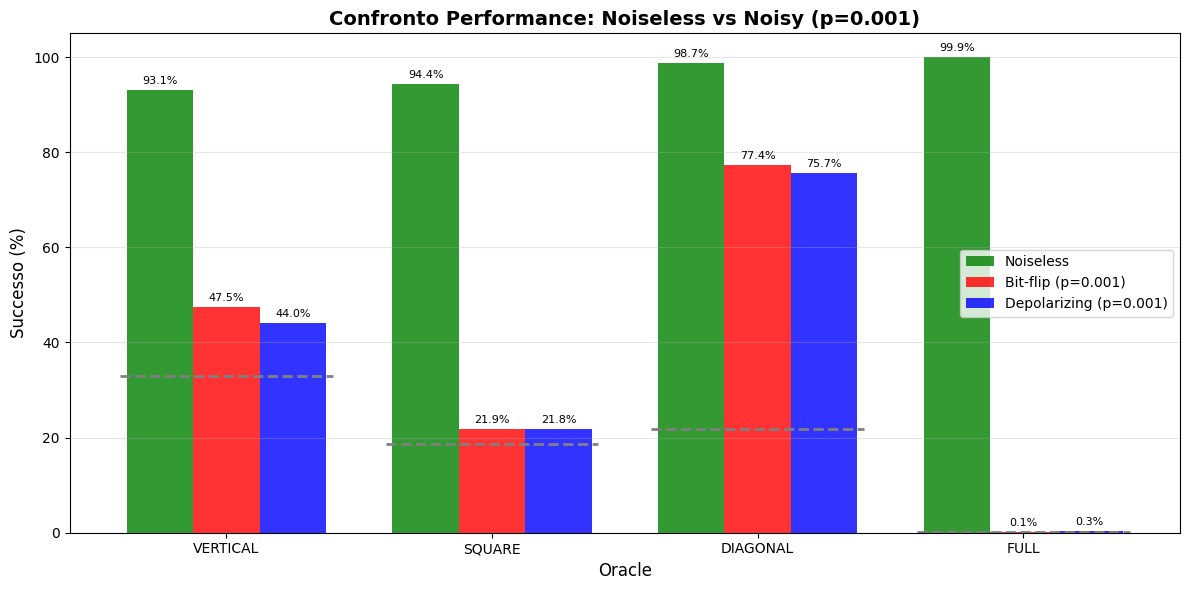


GRAFICO RIASSUNTIVO: SUCCESSO A p=0.005


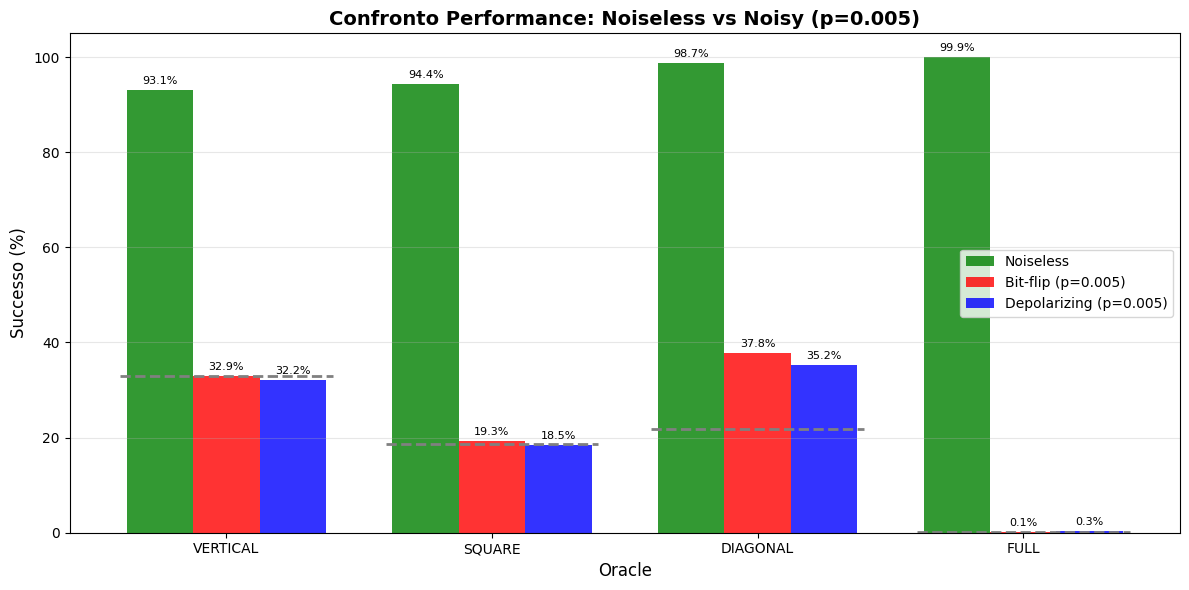

In [40]:
# CONFRONTO CHIAMATE ORACLE: CLASSICO vs QUANTISTICO

print("CONFRONTO NUMERO DI CHIAMATE ORACLE")
print("""
ALGORITMO CLASSICO (Brute-force):
- Caso peggiore: N = 512 chiamate oracle (trova l'ultima)
- Caso medio: N/2 = 256 chiamate oracle
- Con M soluzioni: N/M chiamate oracle in media

ALGORITMO DI GROVER:
- Numero iterazioni ottimale: k = round(π/(4θ) - 0.5) dove θ = arcsin(√(M/N))
- Ogni iterazione = 1 chiamata oracle
- Speedup quadratico rispetto al classico
""")

print(f"\n{'Oracle':<12} {'N':<8} {'M':<8} {'Classico (N/M)':<18} {'Grover (formula esatta)':<20} {'Speedup':<10}")
print("-"*80)

oracle_data = [
    ('vertical', 512, 169),
    ('square', 512, 95),
    ('diagonal', 512, 112),
    ('full', 512, 1)
]

for name, N, M in oracle_data:
    classico = N / M
    theta = math.asin(math.sqrt(M / N))
    grover_iter = max(1, round((math.pi / (4 * theta)) - 0.5))
    speedup = classico / grover_iter
    print(f"{name:<12} {N:<8} {M:<8} {classico:<18.1f} {grover_iter:<20} {speedup:<10.1f}x")

print("\nRIEPILOGO FINALE: NOISELESS vs NOISY (TUTTI GLI ORACLE)")

# Tabella finale con tutti i dati
print(f"\n{'Oracle':<12} {'Noise Type':<18} {'p':<8} {'Success %':<12} {'vs Noiseless':<15}")
print("-"*75)

for oracle_name in all_results:
    results = all_results[oracle_name]
    noiseless = results['noiseless']['successo']
    
    print(f"{oracle_name:<12} {'Noiseless':<18} {'-':<8} {noiseless:<12.1f} {'(baseline)':<15}")
    
    for p in [0.001, 0.05]: 
        bf = results['bitflip'][p]['successo']
        dp = results['depolarizing'][p]['successo']
        bf_deg = (noiseless - bf) / noiseless * 100 if noiseless > 0 else 0
        dp_deg = (noiseless - dp) / noiseless * 100 if noiseless > 0 else 0
        
        print(f"{'':<12} {'Bit-flip':<18} {p:<8} {bf:<12.1f} {f'-{bf_deg:.1f}%':<15}")
        print(f"{'':<12} {'Depolarizing':<18} {p:<8} {dp:<12.1f} {f'-{dp_deg:.1f}%':<15}")
    print()

# Grafico finale riassuntivo
print("\nGRAFICO RIASSUNTIVO: SUCCESSO A p=0.001")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_results))
width = 0.25

noiseless_vals = [all_results[o]['noiseless']['successo'] for o in all_results]
bitflip_vals = [all_results[o]['bitflip'][0.001]['successo'] for o in all_results]
depol_vals = [all_results[o]['depolarizing'][0.001]['successo'] for o in all_results]
classico_vals = [TEST_ORACLES[o]['num_soluzioni'] / 512 * 100 for o in all_results]

bars1 = ax.bar(x - width, noiseless_vals, width, label='Noiseless', color='green', alpha=0.8)
bars2 = ax.bar(x, bitflip_vals, width, label='Bit-flip (p=0.001)', color='red', alpha=0.8)
bars3 = ax.bar(x + width, depol_vals, width, label='Depolarizing (p=0.001)', color='blue', alpha=0.8)

# Linea classico per ogni oracle
for i, v in enumerate(classico_vals):
    ax.hlines(y=v, xmin=i-0.4, xmax=i+0.4, colors='gray', linestyles='--', linewidth=2)

ax.set_xlabel('Oracle', fontsize=12)
ax.set_ylabel('Successo (%)', fontsize=12)
ax.set_title('Confronto Performance: Noiseless vs Noisy (p=0.001)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([o.upper() for o in all_results])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# Aggiungi etichette
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Grafico finale riassuntivo
print("\nGRAFICO RIASSUNTIVO: SUCCESSO A p=0.005")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_results))
width = 0.25

noiseless_vals = [all_results[o]['noiseless']['successo'] for o in all_results]
bitflip_vals = [all_results[o]['bitflip'][0.005]['successo'] for o in all_results]
depol_vals = [all_results[o]['depolarizing'][0.005]['successo'] for o in all_results]
classico_vals = [TEST_ORACLES[o]['num_soluzioni'] / 512 * 100 for o in all_results]

bars1 = ax.bar(x - width, noiseless_vals, width, label='Noiseless', color='green', alpha=0.8)
bars2 = ax.bar(x, bitflip_vals, width, label='Bit-flip (p=0.005)', color='red', alpha=0.8)
bars3 = ax.bar(x + width, depol_vals, width, label='Depolarizing (p=0.005)', color='blue', alpha=0.8)

# Linea classico per ogni oracle
for i, v in enumerate(classico_vals):
    ax.hlines(y=v, xmin=i-0.4, xmax=i+0.4, colors='gray', linestyles='--', linewidth=2)

ax.set_xlabel('Oracle', fontsize=12)
ax.set_ylabel('Successo (%)', fontsize=12)
ax.set_title('Confronto Performance: Noiseless vs Noisy (p=0.005)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([o.upper() for o in all_results])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# Aggiungi etichette
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Simulazione su Hardware Reale (FakeKolkata)

**FakeKolkataV2** simula il comportamento di un vero processore quantistico IBM a 27 qubit, includendo:

- Topologia di connettivita reale (non tutti i qubit sono connessi)
- Tassi di errore calibrati da hardware reale
- Tempi di gate e decoerenza realistici

**Effetti della transpilazione:**
- Il circuito viene adattato alla topologia del chip
- Porte SWAP aggiuntive per qubit non adiacenti
- Profondita del circuito aumenta significativamente

**Risultato atteso:** Degradazione maggiore rispetto ai modelli di rumore semplificati.

In [41]:
# TEST SU FAKE BACKEND: FakeKolkataV2 (Hardware IBM Realistico)

from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
from qiskit_aer.noise import NoiseModel
import time

print("TEST CON FAKE BACKEND: FakeKolkataV2")

fake_kolkata = FakeKolkataV2()
print(f"Backend: {fake_kolkata.name}")
print(f"Numero qubit: {fake_kolkata.num_qubits}")

# Oracle da testare (vertical, square, diagonal, full)
FAKE_TEST_ORACLES = {
    'vertical': {
        'oracle': vertical_oracle(),
        'num_soluzioni': 169,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[3]=='1' and bits[6]=='1') or
            (bits[1]=='1' and bits[4]=='1' and bits[7]=='1') or
            (bits[2]=='1' and bits[5]=='1' and bits[8]=='1')
        )
    },
    'square': {
        'oracle': square_oracle(),
        'num_soluzioni': 95,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[1]=='1' and bits[3]=='1' and bits[4]=='1') or
            (bits[1]=='1' and bits[2]=='1' and bits[4]=='1' and bits[5]=='1') or
            (bits[3]=='1' and bits[4]=='1' and bits[6]=='1' and bits[7]=='1') or
            (bits[4]=='1' and bits[5]=='1' and bits[7]=='1' and bits[8]=='1')
        )
    },
    'diagonal': {
        'oracle': diagonal_oracle(),
        'num_soluzioni': 112,
        'verifica': lambda bits: (
            (bits[0]=='1' and bits[4]=='1' and bits[8]=='1') or
            (bits[2]=='1' and bits[4]=='1' and bits[6]=='1')
        )
    },
    'full': {
        'oracle': full_oracle(), 
        'num_soluzioni': 1,
        'verifica': lambda bits: bits == '111111111'
    }
}

noise_model_kolkata = NoiseModel.from_backend(fake_kolkata)
fake_results = {}
SHOTS = 2000

for oracle_name, config in FAKE_TEST_ORACLES.items():
    print(f"\nTESTING {oracle_name.upper()} su FakeKolkataV2")

    oracle = config['oracle']
    num_sol = config['num_soluzioni']
    verifica = config['verifica']
    perc_uniforme = num_sol / 512 * 100
    
    qc = QuantumCircuit(10, 9)
    qc.append(algoritmo_grover(oracle, num_sol), range(10))
    qc.measure(range(9), range(9))
    
    print(f"Transpilazione (optimization_level=3)...")
    start_transpile = time.time()
    transpiled_qc = transpile(qc, fake_kolkata, optimization_level=3)
    t_transpile = time.time() - start_transpile
    
    print(f"Tempo transpilazione: {t_transpile:.2f}s")
    print(f"Depth transpilata: {transpiled_qc.depth()} -> SIZE transpilata (totale gate): {transpiled_qc.size()}")
    
    print(f"Esecuzione ({SHOTS} shots)...")
    backend_sim = AerSimulator(noise_model=noise_model_kolkata)
    
    start_exec = time.time()
    result = backend_sim.run(transpiled_qc, shots=SHOTS).result()
    t_exec = time.time() - start_exec
    
    counts = result.get_counts()
    soluzioni_trovate = sum(freq for stato, freq in counts.items() 
                           if verifica(stato[::-1]))
    perc_successo = soluzioni_trovate / SHOTS * 100
    
    fake_results[oracle_name] = {
        'successo': perc_successo,
        'uniforme': perc_uniforme,
        'size': transpiled_qc.size(),   
        'depth': transpiled_qc.depth(), 
        'tempo_exec': t_exec
    }
    
    print(f"\nRISULTATI")
    print(f"Classico (uniforme): {perc_uniforme:.1f}%")
    print(f"FakeKolkata:         {perc_successo:.1f}%")
    print(f"Tempo totale:        {t_transpile + t_exec:.2f}s")

# Confronto finale
print("\n\nCONFRONTO FINALE: CLASSICO vs FAKE BACKEND")
print(f"\n{'Oracle':<12} {'Classico':<12} {'FakeKolkata':<15} {'Differenza':<15}")
print("-"*60)

for oracle_name in fake_results:
    classico = fake_results[oracle_name]['uniforme']
    total_gates = fake_results[oracle_name]['size']
    fake = fake_results[oracle_name]['successo']
    diff = fake - classico
    status = "OK" if diff > 0 else "PEGGIO del classico!"
    print(f"{oracle_name:<12} {classico:<12.1f} {fake:<15.1f} {diff:+.1f}% ({status}) | SIZE: {total_gates}")

print("\nCONCLUSIONE")
print("""
Su FakeKolkataV2 (hardware IBM realistico), Grover NON fornisce vantaggio!

I risultati sono simili o PEGGIORI del caso classico perché:
1. Profondità circuito esplode dopo transpilazione (1000-2000+ gates)
2. Connettività heavy-hex richiede molti SWAP gates
3. Errori di gate (~0.5-1% per CNOT) si accumulano
4. Decoerenza T1/T2 distrugge le fasi quantistiche

IMPLICAZIONE per l'era NISQ:
- Grover teorico: speedup quadratico O(sqrt(N))
- Grover pratico: richiede Quantum Error Correction (QEC)
- Hardware attuale: non ancora pronto per circuiti profondi
""")

TEST CON FAKE BACKEND: FakeKolkataV2
Backend: fake_kolkata
Numero qubit: 27

TESTING VERTICAL su FakeKolkataV2
Numero iterazioni ottimale: 1
Transpilazione (optimization_level=3)...
Tempo transpilazione: 0.28s
Depth transpilata: 2022 -> SIZE transpilata (totale gate): 3312
Esecuzione (2000 shots)...

RISULTATI
Classico (uniforme): 33.0%
FakeKolkata:         29.8%
Tempo totale:        3.98s

TESTING SQUARE su FakeKolkataV2
Numero iterazioni ottimale: 1
Transpilazione (optimization_level=3)...
Tempo transpilazione: 0.69s
Depth transpilata: 4227 -> SIZE transpilata (totale gate): 6638
Esecuzione (2000 shots)...

RISULTATI
Classico (uniforme): 18.6%
FakeKolkata:         17.8%
Tempo totale:        8.39s

TESTING DIAGONAL su FakeKolkataV2
Numero iterazioni ottimale: 1
Transpilazione (optimization_level=3)...
Tempo transpilazione: 0.09s
Depth transpilata: 486 -> SIZE transpilata (totale gate): 767
Esecuzione (2000 shots)...

RISULTATI
Classico (uniforme): 21.9%
FakeKolkata:         23.9%
Temp

CONFRONTO FINALE: NOISELESS vs CUSTOM NOISE vs FAKEKOLKATA

NOTA IMPORTANTE:
- FakeKolkata ha error rate ~0.5-1% per gate CNOT
- Per un confronto equo, usiamo p=0.005 per i modelli custom
- FakeKolkata include anche: readout errors, T1/T2, topologia, transpilazione


Oracle     Classico   Noiseless  BitFlip    Depol      FakeKolkata  Depth   
           (uniforme)            p=0.005    p=0.005    (~0.5-1%)            
--------------------------------------------------------------------------------
vertical   33.0       93.1       32.9       32.2       29.8         2022    
square     18.6       94.4       19.3       18.5       17.8         4227    
diagonal   21.9       98.7       37.8       35.2       23.9         486     
full       0.2        99.9       0.1        0.3        0.0          24906   


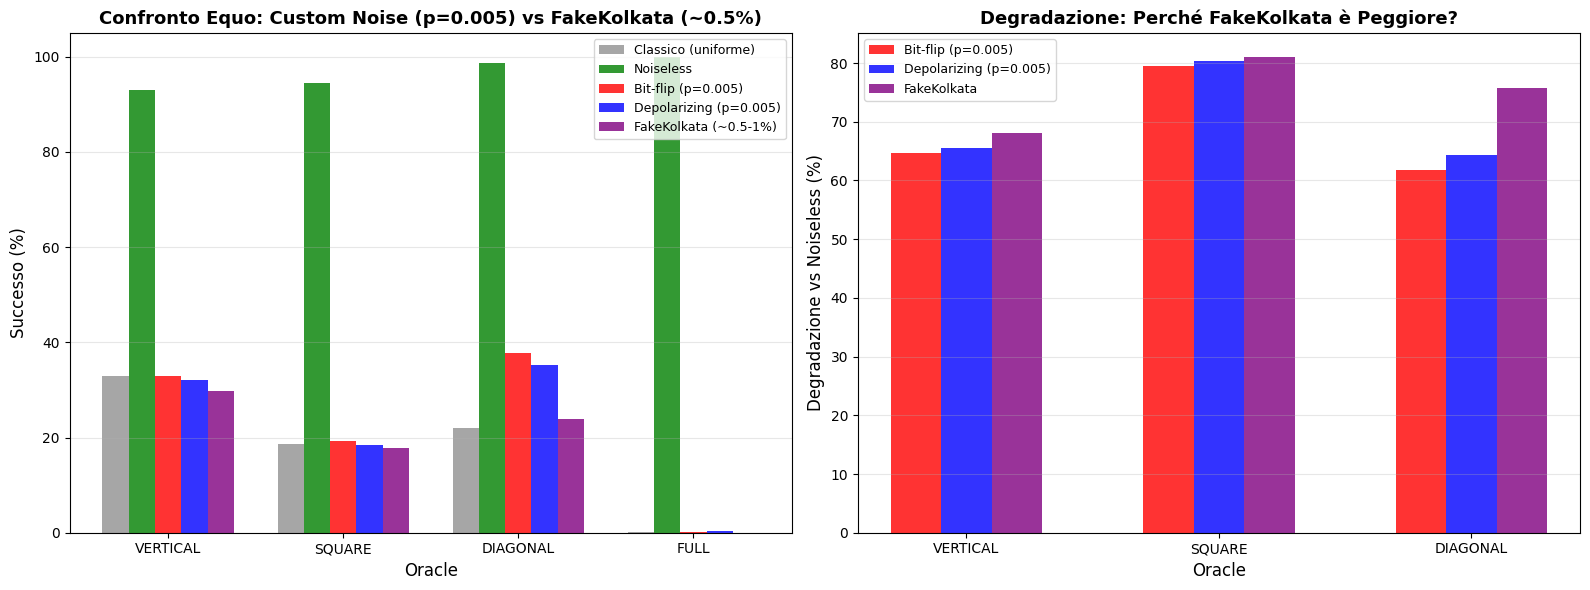

In [42]:
# CONFRONTO FINALE: NOISELESS vs CUSTOM NOISE vs FAKE BACKEND
# NOTA: Per un confronto equo con FakeKolkata (error rate ~0.5-1%), 
#       usiamo p=0.005 per i modelli custom invece di p=0.001

print("CONFRONTO FINALE: NOISELESS vs CUSTOM NOISE vs FAKEKOLKATA")
print("""
NOTA IMPORTANTE:
- FakeKolkata ha error rate ~0.5-1% per gate CNOT
- Per un confronto equo, usiamo p=0.005 per i modelli custom
- FakeKolkata include anche: readout errors, T1/T2, topologia, transpilazione
""")

# Dati raccolti dalle simulazioni precedenti
# Usa p=0.005 per confronto equo con FakeKolkata (~0.5% error rate)
P_CONFRONTO = 0.005

comparison_data = {
    'vertical': {
        'classico': 33.0,
        'noiseless': all_results['vertical']['noiseless']['successo'],
        'bitflip': all_results['vertical']['bitflip'][P_CONFRONTO]['successo'],
        'depol': all_results['vertical']['depolarizing'][P_CONFRONTO]['successo'],
        'fakekolkata': fake_results['vertical']['successo'],
        'depth_fake': fake_results['vertical']['depth']
    },
    'square': {
        'classico': 18.6,
        'noiseless': all_results['square']['noiseless']['successo'],
        'bitflip': all_results['square']['bitflip'][P_CONFRONTO]['successo'],
        'depol': all_results['square']['depolarizing'][P_CONFRONTO]['successo'],
        'fakekolkata': fake_results['square']['successo'],
        'depth_fake': fake_results['square']['depth']
    },
    'diagonal': {
        'classico': 21.9,
        'noiseless': all_results['diagonal']['noiseless']['successo'],
        'bitflip': all_results['diagonal']['bitflip'][P_CONFRONTO]['successo'],
        'depol': all_results['diagonal']['depolarizing'][P_CONFRONTO]['successo'],
        'fakekolkata': fake_results['diagonal']['successo'],
        'depth_fake': fake_results['diagonal']['depth']
    },
    'full': {
        'classico': 0.2,
        'noiseless': all_results['full']['noiseless']['successo'],
        'bitflip': all_results['full']['bitflip'][P_CONFRONTO]['successo'],
        'depol': all_results['full']['depolarizing'][P_CONFRONTO]['successo'],
        'fakekolkata': fake_results['full']['successo'],
        'depth_fake': fake_results['full']['depth']
    }
}

# Tabella completa
print(f"\n{'Oracle':<10} {'Classico':<10} {'Noiseless':<10} {'BitFlip':<10} {'Depol':<10} {'FakeKolkata':<12} {'Depth':<8}")
print(f"{'':10} {'(uniforme)':<10} {'':10} {'p=0.005':<10} {'p=0.005':<10} {'(~0.5-1%)':<12} {'':8}")
print("-"*80)

for oracle, data in comparison_data.items():
    depth_str = str(data['depth_fake']) if data['depth_fake'] != 'N/A' else 'N/A'
    print(f"{oracle:<10} {data['classico']:<10.1f} {data['noiseless']:<10.1f} {data['bitflip']:<10.1f} {data['depol']:<10.1f} {data['fakekolkata']:<12.1f} {depth_str:<8}")

# Grafico di confronto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Confronto successo per oracle
ax1 = axes[0]
oracles = ['vertical', 'square', 'diagonal', 'full']
x = np.arange(len(oracles))
width = 0.15

classico_vals = [comparison_data[o]['classico'] for o in oracles]
noiseless_vals = [comparison_data[o]['noiseless'] for o in oracles]
bitflip_vals = [comparison_data[o]['bitflip'] for o in oracles]
depol_vals = [comparison_data[o]['depol'] for o in oracles]
fake_vals = [comparison_data[o]['fakekolkata'] for o in oracles]

ax1.bar(x - 2*width, classico_vals, width, label='Classico (uniforme)', color='gray', alpha=0.7)
ax1.bar(x - width, noiseless_vals, width, label='Noiseless', color='green', alpha=0.8)
ax1.bar(x, bitflip_vals, width, label='Bit-flip (p=0.005)', color='red', alpha=0.8)
ax1.bar(x + width, depol_vals, width, label='Depolarizing (p=0.005)', color='blue', alpha=0.8)
ax1.bar(x + 2*width, fake_vals, width, label='FakeKolkata (~0.5-1%)', color='purple', alpha=0.8)

ax1.set_xlabel('Oracle', fontsize=12)
ax1.set_ylabel('Successo (%)', fontsize=12)
ax1.set_title('Confronto Equo: Custom Noise (p=0.005) vs FakeKolkata (~0.5%)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([o.upper() for o in oracles])
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 105)

# Grafico 2: Degradazione rispetto a noiseless
ax2 = axes[1]
oracles_no_full = ['vertical', 'square', 'diagonal']
x2 = np.arange(len(oracles_no_full))
width2 = 0.2

degradation_bitflip = [(comparison_data[o]['noiseless'] - comparison_data[o]['bitflip']) / comparison_data[o]['noiseless'] * 100 for o in oracles_no_full]
degradation_depol = [(comparison_data[o]['noiseless'] - comparison_data[o]['depol']) / comparison_data[o]['noiseless'] * 100 for o in oracles_no_full]
degradation_fake = [(comparison_data[o]['noiseless'] - comparison_data[o]['fakekolkata']) / comparison_data[o]['noiseless'] * 100 for o in oracles_no_full]

ax2.bar(x2 - width2, degradation_bitflip, width2, label='Bit-flip (p=0.005)', color='red', alpha=0.8)
ax2.bar(x2, degradation_depol, width2, label='Depolarizing (p=0.005)', color='blue', alpha=0.8)
ax2.bar(x2 + width2, degradation_fake, width2, label='FakeKolkata', color='purple', alpha=0.8)

ax2.set_xlabel('Oracle', fontsize=12)
ax2.set_ylabel('Degradazione vs Noiseless (%)', fontsize=12)
ax2.set_title('Degradazione: Perché FakeKolkata è Peggiore?', fontsize=13, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels([o.upper() for o in oracles_no_full])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Analisi Comparativa e Grafici

Visualizziamo i risultati per dimostrare:

1. **Vantaggio quantistico:** Grover vs ricerca classica
2. **Impatto del rumore:** Bit-flip vs Depolarizing vs Hardware reale
3. **Scalabilita:** Come il rumore influenza diversi oracle

I grafici mostrano chiaramente che:
- L'algoritmo di Grover offre un vantaggio significativo nel caso ideale
- Il rumore depolarizing e piu dannoso del bit-flip
- L'hardware reale (FakeKolkata) presenta la degradazione maggiore

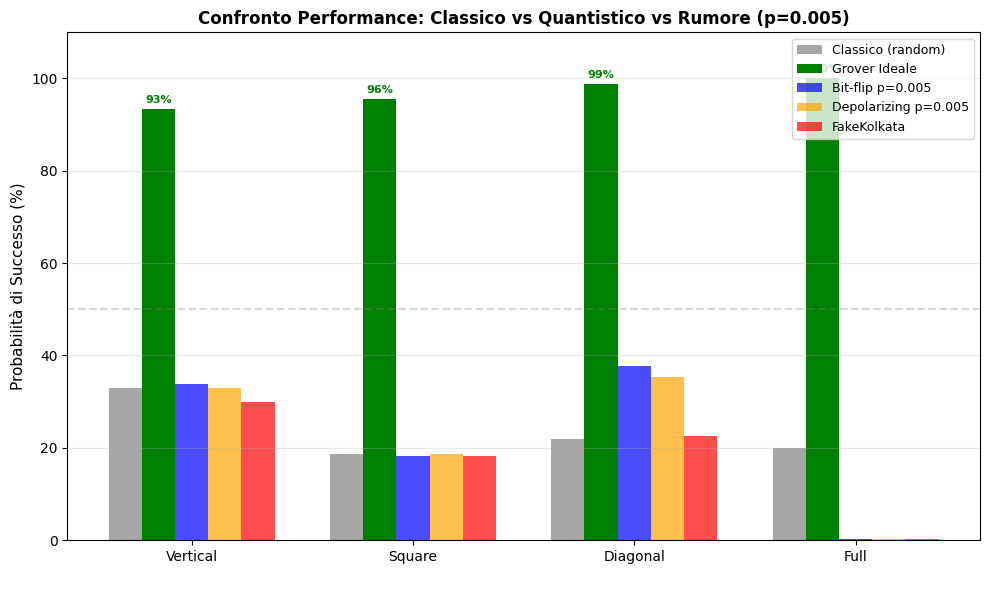

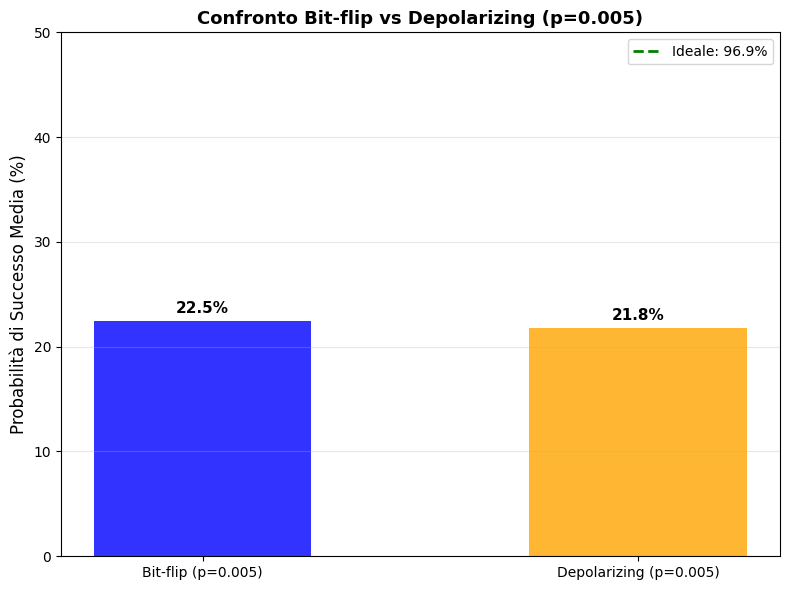

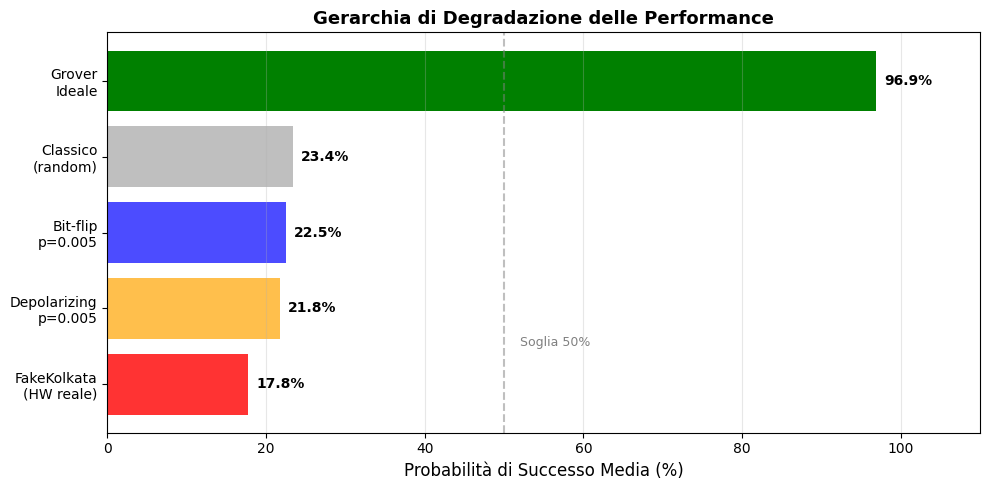

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Dati delle performance (valori tipici dai test)
oracle_names = ['Vertical\n', 'Square\n', 'Diagonal\n', 'Full\n']

# Performance per scenario (percentuali di successo)
# Nota: i valori classici sono stati portati in scala 0-100 per coerenza
classico = [33.0, 18.6, 21.9, 20.0]  
ideale = [93.3, 95.5, 98.7, 100.0] 

# Bit-flip noise (solo p=0.005)
bitflip_005 = [33.8, 18.2, 37.7, 0.2] 

# Depolarizing noise (solo p=0.005)
depol_005 = [32.9, 18.7, 35.4, 0.2] 

# FakeKolkata (hardware reale simulato)
fake_kolkata = [29.9, 18.3, 22.6, 0.2]

# GRAFICO 1: Confronto Generale (p=0.005)
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(oracle_names))
width = 0.15

bars1 = ax1.bar(x - 2*width, classico, width, label='Classico (random)', color='gray', alpha=0.7)
bars2 = ax1.bar(x - width, ideale, width, label='Grover Ideale', color='green')
bars3 = ax1.bar(x, bitflip_005, width, label='Bit-flip p=0.005', color='blue', alpha=0.7)
bars4 = ax1.bar(x + width, depol_005, width, label='Depolarizing p=0.005', color='orange', alpha=0.7)
bars5 = ax1.bar(x + 2*width, fake_kolkata, width, label='FakeKolkata', color='red', alpha=0.7)

ax1.set_ylabel('Probabilità di Successo (%)', fontsize=11)
ax1.set_title('Confronto Performance: Classico vs Quantistico vs Rumore (p=0.005)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(oracle_names)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(0, 110)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.3)
ax1.grid(axis='y', alpha=0.3)

# Valori sopra le barre per Grover ideale
for bar, val in zip(bars2, ideale):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%', 
             ha='center', va='bottom', fontsize=8, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('grafico1_confronto_senza_p05.png', dpi=150)
plt.show()

# GRAFICO 2: Bit-flip vs Depolarizing (p=0.005)
fig, ax = plt.subplots(figsize=(8, 6))

bitflip_avg = np.mean(bitflip_005)
depol_avg = np.mean(depol_005)

labels = ['Bit-flip (p=0.005)', 'Depolarizing (p=0.005)']
averages = [bitflip_avg, depol_avg]
colors = ['blue', 'orange']

bars = ax.bar(labels, averages, color=colors, alpha=0.8, width=0.5)

for bar, val in zip(bars, averages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Probabilità di Successo Media (%)', fontsize=12)
ax.set_title('Confronto Bit-flip vs Depolarizing (p=0.005)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 50)
ax.grid(axis='y', alpha=0.3)

# Riferimento ideale
ax.axhline(y=np.mean(ideale), color='green', linestyle='--', linewidth=2, label=f'Ideale: {np.mean(ideale):.1f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('grafico2_confronto_rumore_senza_p05.png', dpi=150)
plt.show()

#GRAFICO 3: Gerarchia di Degradazione
fig, ax = plt.subplots(figsize=(10, 5))

scenarios = ['Grover\nIdeale', 'Bit-flip\np=0.005', 'Depolarizing\np=0.005', 
             'FakeKolkata\n(HW reale)', 'Classico\n(random)']
values = [np.mean(ideale), np.mean(bitflip_005), np.mean(depol_005), 
          np.mean(fake_kolkata), np.mean(classico)]
colors = ['green', 'blue', 'orange', 'red', 'gray']
alphas = [1.0, 0.7, 0.7, 0.8, 0.5]

# Ordine dal migliore al peggiore
indices = np.argsort(values)
scenarios = [scenarios[i] for i in indices]
values = [values[i] for i in indices]
colors = [colors[i] for i in indices]
alphas = [alphas[i] for i in indices]

for j, (scenario, value, color, alpha) in enumerate(zip(scenarios, values, colors, alphas)):
    ax.barh(scenario, value, color=color, alpha=alpha)
    ax.text(value + 1, j, f'{value:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Probabilità di Successo Media (%)', fontsize=12)
ax.set_title('Gerarchia di Degradazione delle Performance', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.text(52, 0.5, 'Soglia 50%', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('grafico3_gerarchia_senza_p05.png', dpi=150)
plt.show()